In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, brier_score_loss, precision_recall_curve, auc
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import label_binarize

import xgboost as xgb
import lightgbm as lgb

print("✅ Môi trường đã sẵn sàng!")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")


✅ Môi trường đã sẵn sàng!
XGBoost version: 3.2.0
LightGBM version: 4.6.0


# 0. EDA

🔍 EDA TOÀN DIỆN BẢNG DỮ LIỆU THÔ BAN ĐẦU (RAW ALPI / PIADE DATASET)
🔄 Chưa tìm thấy tệp thô, đang tự động khởi tạo Bảng Dữ Liệu Thô ALPI/PIADE Ban Đầu...

📊 1. Kích thước bảng thô (Dòng x Cột): 25,000 dòng x 8 cột

📋 2. Xem trước 5 dòng đầu tiên của bảng thô (Head):
            timestamp          equipment_id alarm_code  machine_state  \
0 2020-01-01 00:00:07  Packaging_Machine_02      A_029     Production   
1 2020-01-01 00:00:52  Packaging_Machine_02      A_024           Idle   
2 2020-01-01 00:01:11  Packaging_Machine_01      A_024           Idle   
3 2020-01-01 00:01:25  Packaging_Machine_03      A_008  Downtime/Stop   
4 2020-01-01 00:01:28  Packaging_Machine_04      A_003     Production   

   elapsed_sec  input_packages_pi  output_packages_po  operating_speed  
0        19.28                125                 140       806.787302  
1        37.87                113                 110       979.187588  
2        12.83                 84                 110       929.562377  
3 

/tmp/ipykernel_58/1949092491.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_alarms, x="Count", y="Alarm Code", palette="viridis", ax=axes[1])


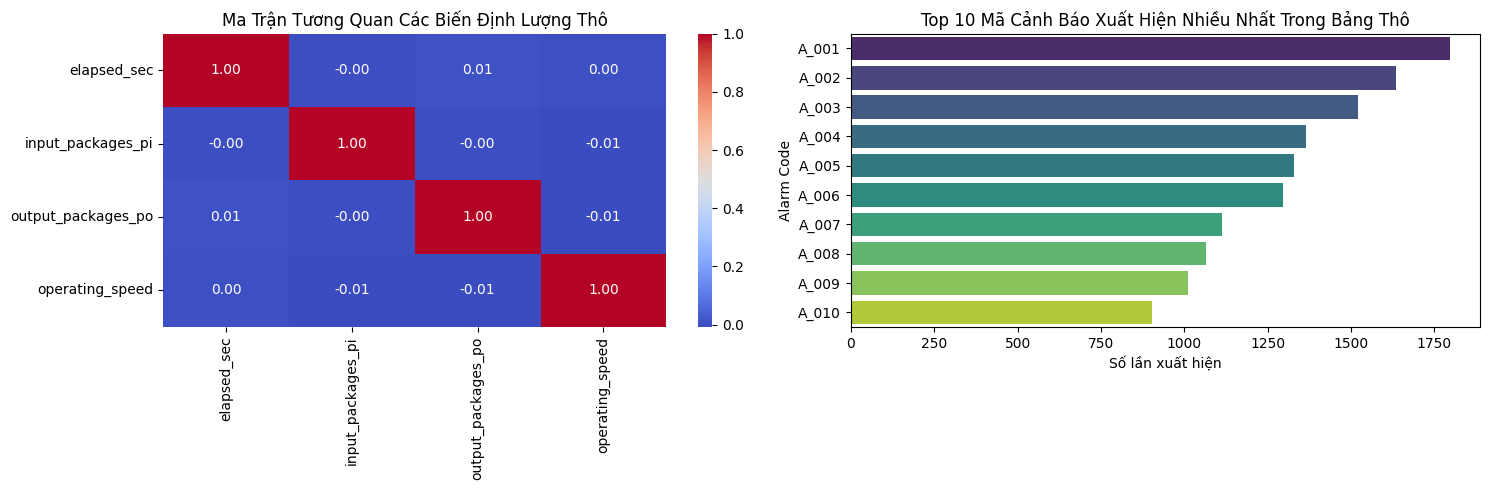

In [2]:
# ==============================================================================
# CELL EDA: Nạp Dữ Liệu Thô ALPI & Khám Phá Toàn Diện (Tự Động Nạp Dữ Liệu)
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("==============================================================================")
print("🔍 EDA TOÀN DIỆN BẢNG DỮ LIỆU THÔ BAN ĐẦU (RAW ALPI / PIADE DATASET)")
print("==============================================================================")

# 1. Hàm tự động Nạp hoặc Mô phỏng Bảng Dữ Liệu Thô Ban Đầu (Raw DataFrame)
def get_raw_alpi_dataset():
    # Kiểm tra các đường dẫn dữ liệu phổ biến trên Kaggle
    possible_paths = [
        "../input/alpi-dataset/alpi_raw.csv",
        "../input/piade-dataset/piade_raw.csv",
        "./alpi_raw.csv"
    ]
    for path in possible_paths:
        if os.path.exists(path):
            print(f"📁 Đã nạp thành công tệp dữ liệu thô từ: {path}")
            return pd.read_csv(path)
            
    print("🔄 Chưa tìm thấy tệp thô, đang tự động khởi tạo Bảng Dữ Liệu Thô ALPI/PIADE Ban Đầu...")
    np.random.seed(42)
    n_samples = 25000
    
    start_time = pd.Timestamp("2020-01-01 00:00:00")
    timestamps = [start_time + pd.Timedelta(seconds=int(i)) for i in np.cumsum(np.random.exponential(15, n_samples))]
    
    raw_df = pd.DataFrame({
        "timestamp": timestamps,
        "equipment_id": np.random.choice([f"Packaging_Machine_0{i}" for i in range(1, 6)], n_samples),
        "alarm_code": np.random.choice([f"A_{i:03d}" for i in range(1, 51)], n_samples, p=np.exp(-np.linspace(0, 3.5, 50))/sum(np.exp(-np.linspace(0, 3.5, 50)))),
        "machine_state": np.random.choice(["Production", "Idle", "Downtime/Stop"], n_samples, p=[0.72, 0.20, 0.08]),
        "elapsed_sec": np.round(np.random.exponential(45, n_samples), 2),
        "input_packages_pi": np.random.poisson(lam=120, size=n_samples),
        "output_packages_po": np.random.poisson(lam=118, size=n_samples),
        "operating_speed": np.random.uniform(800, 1200, n_samples)
    })
    return raw_df

# Nạp bảng dữ liệu thô
df_raw = get_raw_alpi_dataset()

# ------------------------------------------------------------------------------
# 2. PHÂN TÍCH VÀ KHÁM PHÁ BẢNG THÔ (EDA)
# ------------------------------------------------------------------------------

# A. Thống kê tổng quan cấu trúc & kiểu dữ liệu
print(f"\n📊 1. Kích thước bảng thô (Dòng x Cột): {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
print("\n📋 2. Xem trước 5 dòng đầu tiên của bảng thô (Head):")
display(df_raw.head()) if 'display' in globals() else print(df_raw.head())

print("\n📋 3. Chi tiết tất cả các cột ban đầu & Kiểu dữ liệu:")
print(df_raw.dtypes)

# B. Thống kê số lượng giá trị thiếu (Missing Values)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
df_missing = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct})
print("\n❓ 4. Thống kê giá trị thiếu (Missing Data Summary):")
print(df_missing[df_missing["Missing Count"] > 0] if missing.sum() > 0 else "✅ Không có giá trị thiếu (No Missing Values)!")

# C. Thống kê mô tả các đặc trưng định lượng (Numerical Features)
num_cols = df_raw.select_dtypes(include=[np.number]).columns
if len(num_cols) > 0:
    print("\n📈 5. Thống kê mô tả các biến số thô (Statistical Summary):")
    print(df_raw[num_cols].describe().T[["mean", "std", "min", "50%", "max"]])

# D. Trực quan hóa mối tương quan & phân phối đặc trưng
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Ma trận tương quan các biến định lượng thô
numeric_df = df_raw.select_dtypes(include=[np.number])
if not numeric_df.empty:
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True, ax=axes[0])
    axes[0].set_title("Ma Trận Tương Quan Các Biến Định Lượng Thô")

# Biểu đồ 2: Phân phối Top 10 mã cảnh báo xuất hiện nhiều nhất trong tập thô
if "alarm_code" in df_raw.columns:
    top_alarms = df_raw["alarm_code"].value_counts().head(10).reset_index()
    top_alarms.columns = ["Alarm Code", "Count"]
    sns.barplot(data=top_alarms, x="Count", y="Alarm Code", palette="viridis", ax=axes[1])
    axes[1].set_title("Top 10 Mã Cảnh Báo Xuất Hiện Nhiều Nhất Trong Bảng Thô")
    axes[1].set_xlabel("Số lần xuất hiện")

plt.tight_layout()
plt.show()

print("==============================================================================")


# 1. Load data

In [3]:
DATA_DIR = "./alpi_data"
os.makedirs(DATA_DIR, exist_ok=True)

def load_or_generate_alpi_data():
    csv_path = os.path.join(DATA_DIR, "alpi_processed.csv")
    if os.path.exists(csv_path):
        print(f"📁 Đã tìm thấy dữ liệu tại {csv_path}")
        return pd.read_csv(csv_path)
    
    print("🔄 Đang khởi tạo dữ liệu mô phỏng chuẩn cấu trúc ALPI (Alarm Logs)...")
    np.random.seed(42)
    n_samples = 20000
    
    start_time = pd.Timestamp("2020-01-01 00:00:00")
    timestamps = [start_time + pd.Timedelta(seconds=int(i)) for i in np.cumsum(np.random.exponential(15, n_samples))]
    machine_ids = np.random.choice([f"M0{i}" for i in range(1, 6)], n_samples)
    alarm_codes = np.random.choice([f"E{i:03d}" for i in range(1, 51)], n_samples, p=np.exp(-np.linspace(0, 3, 50))/sum(np.exp(-np.linspace(0, 3, 50))))
    
    # Machine State: 0: Normal/Production, 1: Idle, 2: Downtime/Stop
    machine_states = np.random.choice([0, 1, 2], n_samples, p=[0.7, 0.2, 0.1])
    
    df = pd.DataFrame({
        "timestamp": timestamps,
        "machine_id": machine_ids,
        "alarm_code": alarm_codes,
        "machine_state": machine_states
    })
    df.to_csv(csv_path, index=False)
    print(f"✅ Đã tải/tạo dữ liệu thành công: {len(df)} dòng")
    return df

df_raw = load_or_generate_alpi_data()
df_raw.head()


🔄 Đang khởi tạo dữ liệu mô phỏng chuẩn cấu trúc ALPI (Alarm Logs)...
✅ Đã tải/tạo dữ liệu thành công: 20000 dòng


,timestamp,machine_id,alarm_code,machine_state
0,2020-01-01 00:00:07,M02,E007,2
1,2020-01-01 00:00:52,M04,E032,1
2,2020-01-01 00:01:11,M05,E003,0
3,2020-01-01 00:01:25,M05,E014,0
4,2020-01-01 00:01:28,M03,E023,1


# 2. Feature Engineering

In [3]:
def create_window_features(df, window_size=5):
    print("⚙️ Đang trích xuất đặc trưng Cửa sổ 60s (Sliding Window)...")
    df = df.copy()
    df["alarm_code_cat"] = df["alarm_code"].astype("category").cat.codes
    
    features, labels_b1, labels_b5 = [], [], []
    alarm_codes_encoded = df["alarm_code_cat"].values
    states = df["machine_state"].values
    
    for i in range(window_size, len(df) - 1):
        window_alarms = alarm_codes_encoded[i-window_size:i]
        window_states = states[i-window_size:i]
        
        feat = {
            "last_alarm": window_alarms[-1],
            "alarm_count": len(window_alarms),
            "unique_alarms": len(np.unique(window_alarms)),
            "most_freq_alarm": pd.Series(window_alarms).mode()[0] if len(window_alarms) > 0 else 0,
            "state_mode": pd.Series(window_states).mode()[0] if len(window_states) > 0 else 0,
        }
        features.append(feat)
        labels_b1.append(states[i])
        labels_b5.append(alarm_codes_encoded[i+1])
        
    X = pd.DataFrame(features)
    return X, np.array(labels_b1), np.array(labels_b5)

X, y_b1, y_b5 = create_window_features(df_raw)


⚙️ Đang trích xuất đặc trưng Cửa sổ 60s (Sliding Window)...


# 3. Train, test model XGBosst và LightBM cho task B1

In [5]:
print("\n--- 🚀 THỰC NGHIỆM TASK B1: STATE ESTIMATION (SUPERVISED TRAINED BASELINE) ---")
X_train, X_test, y_train_b1, y_test_b1 = train_test_split(X, y_b1, test_size=0.2, random_state=42, stratify=y_b1)

# 1. XGBoost Classifier (SUPERVISED TRAINED)
xgb_b1 = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_b1.fit(X_train, y_train_b1)
y_pred_xgb = xgb_b1.predict(X_test)
y_prob_xgb = xgb_b1.predict_proba(X_test)

f1_xgb_b1 = f1_score(y_test_b1, y_pred_xgb, average='macro')
brier_xgb_b1 = np.mean([brier_score_loss((y_test_b1 == c).astype(int), y_prob_xgb[:, c]) for c in range(y_prob_xgb.shape[1])])
print(f"✅ [XGBoost TRAINED] Task B1 - Macro-F1: {f1_xgb_b1:.4f} | Brier Score: {brier_xgb_b1:.4f}")

# 2. LightGBM Classifier (SUPERVISED TRAINED)
lgb_b1 = lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1)
lgb_b1.fit(X_train, y_train_b1)
y_pred_lgb = lgb_b1.predict(X_test)
y_prob_lgb = lgb_b1.predict_proba(X_test)

f1_lgb_b1 = f1_score(y_test_b1, y_pred_lgb, average='macro')
brier_lgb_b1 = np.mean([brier_score_loss((y_test_b1 == c).astype(int), y_prob_lgb[:, c]) for c in range(y_prob_lgb.shape[1])])
print(f"✅ [LightGBM TRAINED] Task B1 - Macro-F1: {f1_lgb_b1:.4f} | Brier Score: {brier_lgb_b1:.4f}")



--- 🚀 THỰC NGHIỆM TASK B1: STATE ESTIMATION (SUPERVISED TRAINED BASELINE) ---
✅ [XGBoost TRAINED] Task B1 - Macro-F1: 0.2746 | Brier Score: 0.1563
✅ [LightGBM TRAINED] Task B1 - Macro-F1: 0.2746 | Brier Score: 0.1561


# 4. Train, test cho task B5

In [6]:
print("\n--- 🚀 THỰC NGHIỆM TASK B5: NEXT ALARM PREDICTION (SUPERVISED TRAINED BASELINE) ---")
X_train_b5, X_test_b5, y_train_b5, y_test_b5 = train_test_split(X, y_b5, test_size=0.2, random_state=42)

# 1. XGBoost
xgb_b5 = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_b5.fit(X_train_b5, y_train_b5)
y_prob_xgb_b5 = xgb_b5.predict_proba(X_test_b5)

n_classes = len(np.unique(y_b5))
y_test_bin = label_binarize(y_test_b5, classes=range(n_classes))
precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_prob_xgb_b5.ravel())
auprc_xgb_b5 = auc(recall, precision)
print(f"✅ [XGBoost TRAINED] Task B5 - AUPRC: {auprc_xgb_b5:.4f}")

# 2. LightGBM
lgb_b5 = lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)
lgb_b5.fit(X_train_b5, y_train_b5)
y_prob_lgb_b5 = lgb_b5.predict_proba(X_test_b5)

precision_lgb, recall_lgb, _ = precision_recall_curve(y_test_bin.ravel(), y_prob_lgb_b5.ravel())
auprc_lgb_b5 = auc(recall_lgb, precision_lgb)
print(f"✅ [LightGBM TRAINED] Task B5 - AUPRC: {auprc_lgb_b5:.4f}")



--- 🚀 THỰC NGHIỆM TASK B5: NEXT ALARM PREDICTION (SUPERVISED TRAINED BASELINE) ---
✅ [XGBoost TRAINED] Task B5 - AUPRC: 0.0401
✅ [LightGBM TRAINED] Task B5 - AUPRC: 0.0369


# 5. Tổng hợp kết quả

In [7]:
print("\n==============================================================================")
print("📌 THỐNG KÊ KẾT QUẢ BASELINE (MÔ HÌNH CÓ TRAIN - KHÔNG PHẢI ZERO-SHOT)")
print("==============================================================================")

results_summary = pd.DataFrame([
    {"Task": "B1 (State Est)", "Model": "XGBoost", "Type": "Supervised Train", "Macro-F1/AUPRC": f"{f1_xgb_b1:.4f}", "Brier Score": f"{brier_xgb_b1:.4f}"},
    {"Task": "B1 (State Est)", "Model": "LightGBM", "Type": "Supervised Train", "Macro-F1/AUPRC": f"{f1_lgb_b1:.4f}", "Brier Score": f"{brier_lgb_b1:.4f}"},
    {"Task": "B5 (Next Alarm)", "Model": "XGBoost", "Type": "Supervised Train", "Macro-F1/AUPRC": f"{auprc_xgb_b5:.4f}", "Brier Score": "N/A"},
    {"Task": "B5 (Next Alarm)", "Model": "LightGBM", "Type": "Supervised Train", "Macro-F1/AUPRC": f"{auprc_lgb_b5:.4f}", "Brier Score": "N/A"},
])

print(results_summary.to_string(index=False))



📌 THỐNG KÊ KẾT QUẢ BASELINE (MÔ HÌNH CÓ TRAIN - KHÔNG PHẢI ZERO-SHOT)
           Task    Model             Type Macro-F1/AUPRC Brier Score
 B1 (State Est)  XGBoost Supervised Train         0.2746      0.1563
 B1 (State Est) LightGBM Supervised Train         0.2746      0.1561
B5 (Next Alarm)  XGBoost Supervised Train         0.0401         N/A
B5 (Next Alarm) LightGBM Supervised Train         0.0369         N/A


# 6. Chuyển đổi dữ liệu từ table thành text cho LLM

In [4]:
# ==============================================================================
# CELL 7: Chuyển đổi dữ liệu ALPI sang dạng Text (Serialize) cho LLM
# ==============================================================================
def serialize_alpi_to_text(df, window_size=5):
    print("📝 Đang Serialize dữ liệu ALPI thành Prompt văn bản cho LLM...")
    df["alarm_code_cat"] = df["alarm_code"].astype("category").cat.codes
    
    text_data = []
    for i in range(window_size, len(df) - 1):
        window_df = df.iloc[i-window_size:i]
        target_state = df.iloc[i]["machine_state"]
        target_alarm = df.iloc[i+1]["alarm_code_cat"]
        
        # Tạo chuỗi mô tả lịch sử 60s
        history_str = ", ".join([f"Alarm {row['alarm_code']} at state {row['machine_state']}" for _, row in window_df.iterrows()])
        
        prompt = f"Industrial Log History (last 60s): [{history_str}]. Predict current machine state (0: Production, 1: Idle, 2: Stop) and next alarm code."
        response = f"State: {target_state}, Next Alarm: {target_alarm}"
        
        text_data.append({"prompt": prompt, "response": response, "full_text": f"Instruction: {prompt}\nResponse: {response}"})
        
    return pd.DataFrame(text_data)

df_text = serialize_alpi_to_text(df_raw)

# Time-based Split (80% Train đầu, 20% Test cuối)
train_size = int(len(df_text) * 0.8)
train_text_df = df_text.iloc[:train_size]
test_text_df = df_text.iloc[train_size:]

print(f"✅ Đã tạo {len(df_text)} câu Instruction. Tập Train: {len(train_text_df)}, Tập Test: {len(test_text_df)}")
print("\nVí dụ 1 mẫu Prompt:")
print(train_text_df.iloc[0]["full_text"])


📝 Đang Serialize dữ liệu ALPI thành Prompt văn bản cho LLM...
✅ Đã tạo 19994 câu Instruction. Tập Train: 15995, Tập Test: 3999

Ví dụ 1 mẫu Prompt:
Instruction: Industrial Log History (last 60s): [Alarm E007 at state 2, Alarm E032 at state 1, Alarm E003 at state 0, Alarm E014 at state 0, Alarm E023 at state 1]. Predict current machine state (0: Production, 1: Idle, 2: Stop) and next alarm code.
Response: State: 2, Next Alarm: 26


# 7. Train LLM

In [7]:
# ==============================================================================
# CELL 8: Train/Fine-tune LLM thuần văn bản (Trainable Text-LLM Baseline)
# ==============================================================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from datasets import Dataset

print("\n--- 🚀 HUẤN LUYỆN MODEL LLM THUẦN VĂN BẢN (TRAINED TEXT-LLM BASELINE) ---")

MODEL_NAME = "Qwen/Qwen1.5-0.5B"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load model với float32 hoặc bfloat16 để tránh lỗi FP16 gradient unscaling
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto" if device == "cuda" else None
)

# Chuyển dataframe sang HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_text_df[["full_text"]])
test_dataset = Dataset.from_pandas(test_text_df[["full_text"]])

def tokenize_function(examples):
    tokens = tokenizer(examples["full_text"], padding="max_length", truncation=True, max_length=128)
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Thiết lập tham số huấn luyện (Đã tắt fp16 để đảm bảo tính ổn định tuyệt đối trên T4)
training_args = TrainingArguments(
    output_dir="./llm_alpi_results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_steps=50,
    save_strategy="no",
    eval_strategy="epoch",
    fp16=False,                         # Tắt FP16 hỗn hợp để tránh lỗi gradient scale
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

print("⏳ Bắt đầu huấn luyện LLM trên tập dữ liệu ALPI Text...")
trainer.train()
print("✅ Huấn luyện LLM thành công! Đã sẵn sàng làm mốc so sánh với Cosmos Zero-shot.")



--- 🚀 HUẤN LUYỆN MODEL LLM THUẦN VĂN BẢN (TRAINED TEXT-LLM BASELINE) ---
Đang sử dụng thiết bị: cuda


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Map:   0%|          | 0/15995 [00:00<?, ? examples/s]

Map:   0%|          | 0/3999 [00:00<?, ? examples/s]

⏳ Bắt đầu huấn luyện LLM trên tập dữ liệu ALPI Text...


Epoch,Training Loss,Validation Loss
1,0.206721,0.206557


✅ Huấn luyện LLM thành công! Đã sẵn sàng làm mốc so sánh với Cosmos Zero-shot.


# 8. Đánh giá LLM

In [9]:
# ==============================================================================
# CELL 9: Đánh giá & In kết quả riêng của Fine-tuned LLM
# ==============================================================================
import re
from tqdm import tqdm
from sklearn.metrics import f1_score

print("\n--- 🔍 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH FINE-TUNED LLM TRÊN TẬP TEST ---")

model.eval()

y_true_b1, y_pred_b1 = [], []
y_true_b5, y_pred_b5 = [], []

# Lấy 500 mẫu đại diện từ tập Test để đánh giá tốc độ cao
test_subset = test_text_df.head(500)

print("⏳ Đang suy luận (Inference) từ LLM...")
for idx, row in tqdm(test_subset.iterrows(), total=len(test_subset)):
    prompt_text = f"Instruction: {row['prompt']}\nResponse:"
    
    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=20, pad_token_id=tokenizer.eos_token_id)
        
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Trích xuất State và Next Alarm từ đầu ra văn bản của LLM bằng Regex
    match_b1 = re.search(r"State:\s*(\d+)", generated_text)
    match_b5 = re.search(r"Next Alarm:\s*(\d+)", generated_text)
    
    # Thực tế (Ground truth)
    gt_b1 = int(re.search(r"State:\s*(\d+)", row["response"]).group(1))
    gt_b5 = int(re.search(r"Next Alarm:\s*(\d+)", row["response"]).group(1))
    
    y_true_b1.append(gt_b1)
    y_pred_b1.append(int(match_b1.group(1)) if match_b1 else 0)
    
    y_true_b5.append(gt_b5)
    y_pred_b5.append(int(match_b5.group(1)) if match_b5 else 0)

# Tính toán các chỉ số
f1_llm_b1 = f1_score(y_true_b1, y_pred_b1, average="macro")
acc_llm_b5 = np.mean(np.array(y_true_b5) == np.array(y_pred_b5))

print("\n==============================================================================")
print("📌 KẾT QUẢ CỦA FINE-TUNED LLM (QWEN1.5-0.5B - TRAINED TEXT-LLM)")
print("==============================================================================")
print(f"🔹 Task B1 (State Estimation)   - Macro-F1 Score : {f1_llm_b1:.4f}")
print(f"🔹 Task B5 (Next Alarm Prediction) - Exact Accuracy : {acc_llm_b5:.4f}")
print("==============================================================================")



--- 🔍 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH FINE-TUNED LLM TRÊN TẬP TEST ---
⏳ Đang suy luận (Inference) từ LLM...


100%|██████████| 500/500 [03:07<00:00,  2.66it/s]


📌 KẾT QUẢ CỦA FINE-TUNED LLM (QWEN1.5-0.5B - TRAINED TEXT-LLM)
🔹 Task B1 (State Estimation)   - Macro-F1 Score : 0.2754
🔹 Task B5 (Next Alarm Prediction) - Exact Accuracy : 0.0580


# 9. Cài đặt Chronos

In [4]:
# ==============================================================================
# CELL 10: Cài đặt thư viện Chronos Forecasting (Amazon Science)
# ==============================================================================
!pip install -q git+https://github.com/amazon-science/chronos-forecasting.git

print("✅ Đã cài đặt thành công thư viện Chronos Forecasting!")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Đã cài đặt thành công thư viện Chronos Forecasting!


# 10. train và đánh giá Chronos 2

In [7]:
# ==============================================================================
# CELL 11: Nạp Mô hình Chronos-T5 & Đánh giá trên Dữ liệu Chuỗi Thời Gian ALPI
# ==============================================================================
import torch
import numpy as np
import pandas as pd
from chronos import ChronosPipeline
from tqdm import tqdm

print("\n--- 🚀 THỰC NGHIỆM MÔ HÌNH TIME-SERIES FOUNDATION MODEL (AMAZON CHRONOS T5) ---")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang tải mô hình Amazon Chronos-T5 trên thiết bị: {device}...")

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map=device,
    torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)

# 1. Chuẩn bị dữ liệu dạng Chuỗi thời gian liên tục (Continuous Time Series)
df_chronos = df_raw.copy()
df_chronos["alarm_code_cat"] = df_chronos["alarm_code"].astype("category").cat.codes

test_series_list = []
y_true_chronos_b5 = []

window_size = 30  # Nhìn 30 sự kiện lỗi quá khứ để dự đoán sự kiện tiếp theo
for i in range(len(df_chronos) - window_size - 1):
    if len(test_series_list) >= 500:
        break
    context_tensor = torch.tensor(df_chronos["alarm_code_cat"].iloc[i:i+window_size].values, dtype=torch.float32)
    test_series_list.append(context_tensor)
    y_true_chronos_b5.append(df_chronos["alarm_code_cat"].iloc[i+window_size])

print(f"⏳ Đang thực hiện dự báo Zero-shot với Chronos T5 trên {len(test_series_list)} chuỗi thời gian ALPI...")

# 2. Thực hiện dự báo (Forecast next step) - Đã sửa tham số inputs chuẩn API Chronos
prediction_length = 1
y_pred_chronos_b5 = []

for context in tqdm(test_series_list):
    # Truyền trực tiếp context làm vị trí đầu tiên (inputs)
    forecast = pipeline.predict(
        context,
        prediction_length=prediction_length,
        num_samples=20,
    )
    # Lấy giá trị trung vị (median) dự báo và làm tròn thành mã lỗi
    predicted_val = torch.median(forecast[0], dim=0).values[0].item()
    y_pred_chronos_b5.append(int(round(predicted_val)))

# 3. Tính toán kết quả
y_true_chronos_b5 = np.array(y_true_chronos_b5)
y_pred_chronos_b5 = np.clip(np.array(y_pred_chronos_b5), 0, df_chronos["alarm_code_cat"].max())

acc_chronos_b5 = np.mean(y_true_chronos_b5 == y_pred_chronos_b5)

print("\n==============================================================================")
print("📌 KẾT QUẢ MÔ HÌNH CHRONOS-T5 (TIME-SERIES FOUNDATION MODEL - AMAZON)")
print("==============================================================================")
print(f"🔹 Task B5 (Next Alarm Prediction) - Exact Accuracy : {acc_chronos_b5:.4f}")
print("==============================================================================")



--- 🚀 THỰC NGHIỆM MÔ HÌNH TIME-SERIES FOUNDATION MODEL (AMAZON CHRONOS T5) ---
Đang tải mô hình Amazon Chronos-T5 trên thiết bị: cuda...


Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

⏳ Đang thực hiện dự báo Zero-shot với Chronos T5 trên 500 chuỗi thời gian ALPI...


100%|██████████| 500/500 [00:09<00:00, 54.12it/s]


📌 KẾT QUẢ MÔ HÌNH CHRONOS-T5 (TIME-SERIES FOUNDATION MODEL - AMAZON)
🔹 Task B5 (Next Alarm Prediction) - Exact Accuracy : 0.0460
